In [1]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 

import numpy as np 
import matplotlib.pyplot as plt 
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

In [2]:
import os 
os.listdir('data')


['AEP_hourly.csv',
 'COMED_hourly.csv',
 'DAYTON_hourly.csv',
 'DEOK_hourly.csv',
 'DOM_hourly.csv',
 'DUQ_hourly.csv',
 'EKPC_hourly.csv',
 'est_hourly.paruqet',
 'FE_hourly.csv',
 'NI_hourly.csv',
 'PJME_hourly.csv',
 'PJMW_hourly.csv',
 'pjm_hourly_est.csv',
 'PJM_Load_hourly.csv']

In [3]:
df = pd.read_csv("./data/PJME_hourly.csv", parse_dates=["Datetime"]).sort_values("Datetime").reset_index(drop=True)

In [4]:
print(df.shape)
print(df.head()) 
print(df["Datetime"].min(), "->", df["Datetime"].max())

(145366, 2)
             Datetime  PJME_MW
0 2002-01-01 01:00:00  30393.0
1 2002-01-01 02:00:00  29265.0
2 2002-01-01 03:00:00  28357.0
3 2002-01-01 04:00:00  27899.0
4 2002-01-01 05:00:00  28057.0
2002-01-01 01:00:00 -> 2018-08-03 00:00:00


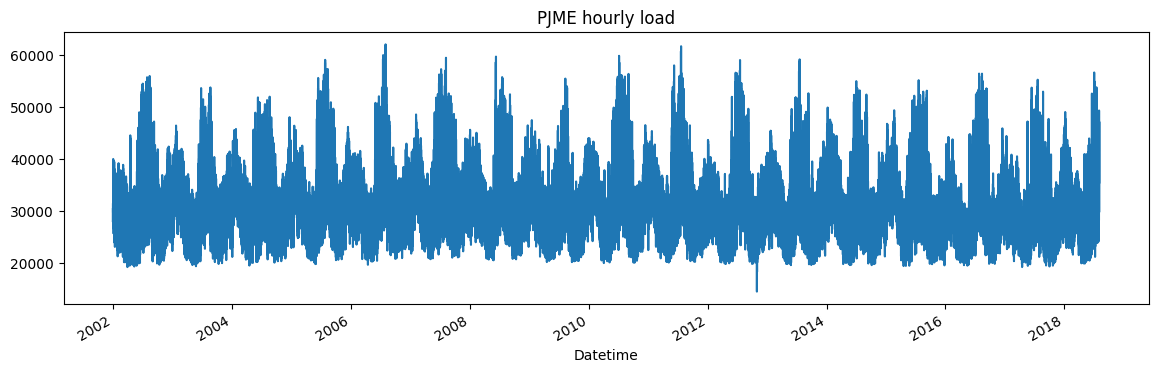

In [5]:
df.set_index("Datetime")["PJME_MW"].plot(figsize=(14,4)) 
plt.title("PJME hourly load")
plt.show()

In [6]:
def preprocess_data_multichannel(
        df,                                           # full DataFrame with Datetime + PJME_MW
        window: int = 168,
        horizon: int = 24,
        train_test_split: float = 0.8
):
    """
    Multi-channel input:
      ch 0: load (z-scored)
      ch 1: hour-of-day sin
      ch 2: hour-of-day cos
      ch 3: day-of-week sin
      ch 4: day-of-week cos
      ch 5: month sin
      ch 6: month cos
    """
    # Extract cyclical features from datetime
    dt = pd.to_datetime(df["Datetime"])
    hour = dt.dt.hour.values
    dow = dt.dt.dayofweek.values
    month = dt.dt.month.values

    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    dow_sin = np.sin(2 * np.pi * dow / 7)
    dow_cos = np.cos(2 * np.pi * dow / 7)
    month_sin = np.sin(2 * np.pi * (month - 1) / 12)
    month_cos = np.cos(2 * np.pi * (month - 1) / 12)

    load = df["PJME_MW"].to_numpy().astype(np.float32)

    # Stack into (n_features, n_timesteps)
    features = np.stack([
        load,
        hour_sin, hour_cos,
        dow_sin, dow_cos,
        month_sin, month_cos,
    ], axis=0).astype(np.float32)                    # shape (7, T)

    features_t = torch.from_numpy(features)          # (7, T)

    # Build windows: (T - window - horizon + 1, 7, window+horizon)
    # unfold creates (7, n_windows, window+horizon), permute to put windows first
    windows = features_t.unfold(1, window + horizon, 1).permute(1, 0, 2)
    # shape: (n_windows, 7, window+horizon)

    split = int(train_test_split * len(windows))
    full_train = windows[:split]
    full_test = windows[split:]

    # Z-score ONLY the load channel using train inputs
    train_load_inputs = full_train[:, 0, :window]    # (n_train, window)
    mean = train_load_inputs.mean()
    std = train_load_inputs.std()
    print(f"Load train mean: {mean.item():.2f}, std: {std.item():.2f}")

    # Apply normalization to channel 0 only (cyclical features already in [-1, 1])
    full_train_z = full_train.clone()
    full_test_z = full_test.clone()
    full_train_z[:, 0] = (full_train[:, 0] - mean) / std
    full_test_z[:, 0] = (full_test[:, 0] - mean) / std

    # Slice into X (input window) and Y (forecast horizon, load only)
    X_train = full_train_z[:, :, :window]            # (n_train, 7, window)
    Y_train = full_train_z[:, 0, window:]            # (n_train, horizon) — load only
    X_test = full_test_z[:, :, :window]
    Y_test = full_test_z[:, 0, window:]

    print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
    print(f"X_test:  {X_test.shape}, Y_test:  {Y_test.shape}")

    train_ds = TensorDataset(X_train, Y_train)
    test_ds = TensorDataset(X_test, Y_test)
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

    return train_loader, test_loader, mean.item(), std.item()


train_loader, test_loader, mean, std = preprocess_data_multichannel(
    df, window=168, horizon=24
)

Load train mean: 32330.68, std: 6435.77
X_train: torch.Size([116140, 7, 168]), Y_train: torch.Size([116140, 24])
X_test:  torch.Size([29035, 7, 168]), Y_test:  torch.Size([29035, 24])


In [7]:
def calculate_optimal_window(kernel: int, dilations: tuple): 
    receptive_field = 1 + (kernel - 1) * sum(dilations) 
    return receptive_field 
  


In [8]:
calculate_optimal_window(3, (1, 2, 4, 8, 16, 32))

127

In [15]:
class TCN(nn.Module): 
    """ 
    Bare TCN is just CausalCNNDilated + residual connections 
    """ 
    def __init__(
            self, 
            in_ch: int = 1, 
            hidden: int = 128, 
            kernel: int = 3, 
            dilations: tuple = (1, 2, 4, 8 ,16), 
            out_size: int = 1,
            verbose: bool = False 
    ): 
        super().__init__() 
        self.kernel = kernel 
        self.dilations = dilations 
        self.verbose = verbose 
        self.convs = nn.ModuleList() 
        # 1x1 projections for layer 0 only (in_ch -> hidden mismatch) 
        self.skip_proj = nn.Conv1d(in_ch, hidden, kernel_size=1) if in_ch != hidden else None 
        for i, d in enumerate(dilations): 
            in_c = in_ch if i == 0 else hidden 
            self.convs.append(nn.Conv1d(in_c, hidden, kernel, dilation=d)) 
        self.head = nn.Linear(hidden, out_size) 
    
    @property 
    def receptive_field(self) -> int: 
        return 1 + (self.kernel - 1) * sum(self.dilations) 
    
    def assert_receptive_field(self, x): 
        window = x.shape[-1] 
        assert window >= self.receptive_field, (
            f"Window={window} < RF={self.receptive_field}"
            "Deeper layers will convolve mostly over padding zeros."
            "Increase window or reduce dilations"
        ) 

    def forward(self, x): 
        self.assert_receptive_field(x)
        for i, (d, conv) in enumerate(zip(self.dilations, self.convs)): 
            pad = (self.kernel - 1) * d 
            x_padded = F.pad(x, (pad, 0)) 
            out = F.relu(conv(x_padded)) 

            # residual connections 
            if i == 0 and self.skip_proj is not None: 
                residual = self.skip_proj(x) 
            else: 
                residual = x
            x = out + residual 
            if self.verbose: 
                print(f"after conv (d={d}): {x.shape}") 
        x = x[:, :, -1]
        return self.head(x)

In [16]:
from datetime import datetime

def train_test_loop(
        model: nn.Module,
        train_loader: DataLoader,
        test_loader: DataLoader,
        lr: float = 1e-3,
        epochs: int = 5
    ):
    start = datetime.now()
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    for epoch in range(epochs): 
        print(f"Epoch: {epoch}")
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            train_losses.append(loss.item())
        avg_loss = running_loss / len(train_loader) 
        # print(f"Epoch {epoch+1:3d}: MSE = {avg_loss:.4f}")
    end = datetime.now()
    training_time = (end - start).total_seconds()
    print(f"Total Training Time: {training_time:.1f} seconds")

    # test loop
    model.eval()
    test_loss = 0
    test_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            test_loss += loss.item()
            test_losses.append(loss.item())
    test_mse = test_loss / len(test_loader)
    print(f"Test MSE: {test_mse:.6f}")
    test_mse_mw = test_mse * (std ** 2)              # MSE scales with variance, hence std²
    test_rmse_mw = np.sqrt(test_mse_mw)              # RMSE in MW
    print(f"Test RMSE (MW): {test_rmse_mw:.0f}")
    return test_mse, np.array(test_losses), np.array(train_losses)

In [17]:
model = TCN(
    in_ch=7,
    hidden=64,                                       # 128 was overkill, drop back
    kernel=3,
    dilations=(1, 2, 4, 8, 16, 32),
    out_size=24,
)

In [18]:
tcn_test_mse, tcn_test_losses, tcn_train_losses = train_test_loop( 
    model=model,
    train_loader=train_loader, 
    test_loader=test_loader, 
    epochs=2
)

Epoch: 0
Epoch: 1
Total Training Time: 118.2 seconds
Test MSE: 0.089798
Test RMSE (MW): 1929


In [19]:
# Seasonal naïve: prediction for next 24h = same 24h from one week ago
# In your sliding-window setup, the first 24h of the input window IS one week ago

import numpy as np

# Iterate test loader, compute naive baseline in z-scored space, then de-normalize
naive_mses = []
for xb, yb in test_loader:
    # xb shape: (batch, 1, 168). Take first 24h of input as the prediction.
    pred_naive = xb[:, 0, :24]                # (batch, 24)
    mse = ((pred_naive - yb) ** 2).mean().item()
    naive_mses.append(mse)

naive_mse_z = np.mean(naive_mses)
naive_rmse_mw = np.sqrt(naive_mse_z * std**2)
print(f"Seasonal naïve RMSE (MW): {naive_rmse_mw:.0f}")

Seasonal naïve RMSE (MW): 4670


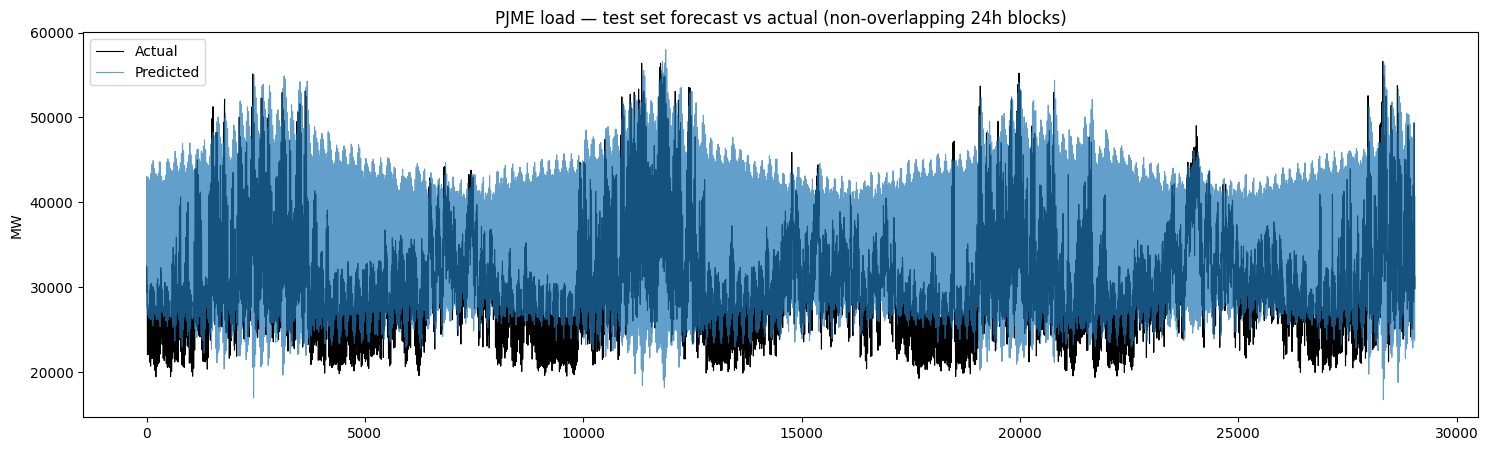

In [21]:
model = TCN(
    in_ch=7,
    hidden=64,                                       # 128 was overkill, drop back
    kernel=3,
    dilations=(1, 2, 4, 8, 16, 32),
    out_size=24,
)
preds_all, actuals_all = [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        preds_all.append(model(xb))
        actuals_all.append(yb)
preds_all = torch.cat(preds_all).numpy()       # (N, 24) z-scored
actuals_all = torch.cat(actuals_all).numpy()

# De-normalize
preds_mw = preds_all * std + mean
actuals_mw = actuals_all * std + mean

# Non-overlapping forecasts (every 24th sample → flatten 24-hour blocks)
step = 24
preds_flat = preds_mw[::step].flatten()
actuals_flat = actuals_mw[::step].flatten()

plt.figure(figsize=(18, 5))
plt.plot(actuals_flat, color="black", linewidth=0.8, label="Actual")
plt.plot(preds_flat, color="C0", linewidth=0.8, alpha=0.7, label="Predicted")
plt.title("PJME load — test set forecast vs actual (non-overlapping 24h blocks)")
plt.ylabel("MW")
plt.legend()
plt.show()

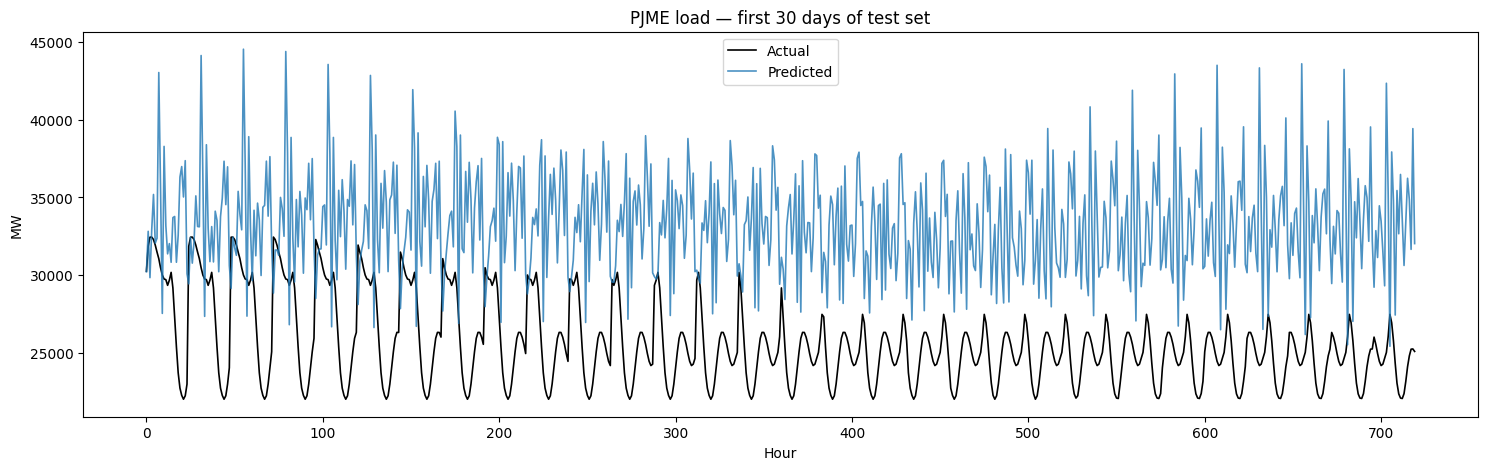

In [22]:
# Plot first ~30 days of test set (720 hours ≈ 30 non-overlapping 24h blocks)
n_blocks = 30
plt.figure(figsize=(18, 5))
plt.plot(actuals_mw[:n_blocks].flatten(), "black", label="Actual", linewidth=1.2)
plt.plot(preds_mw[:n_blocks].flatten(), "C0", label="Predicted", linewidth=1.2, alpha=0.8)
plt.title("PJME load — first 30 days of test set")
plt.ylabel("MW")
plt.xlabel("Hour")
plt.legend()
plt.show()

In [23]:
# Check if predictions in z-space have reasonable distribution
print(f"Predictions z-space: mean={preds_all.mean():.3f}, std={preds_all.std():.3f}")
print(f"Actuals z-space:     mean={actuals_all.mean():.3f}, std={actuals_all.std():.3f}")

Predictions z-space: mean=0.194, std=0.755
Actuals z-space:     mean=-0.194, std=1.008


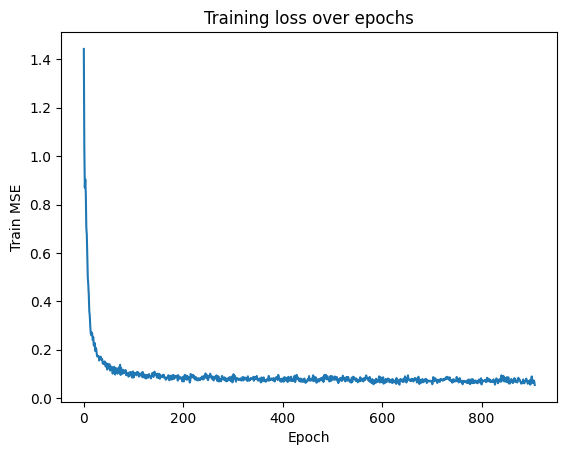

In [24]:
# Inside your training loop, accumulate a list of train_losses
# After training:
plt.plot(tcn_train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training loss over epochs")
plt.show()

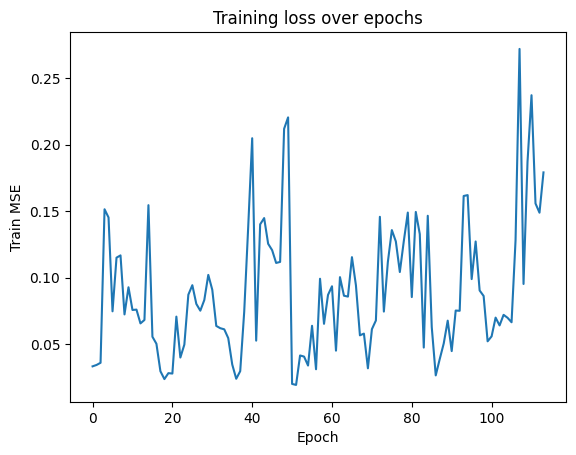

In [25]:
# Inside your training loop, accumulate a list of train_losses
# After training:
plt.plot(tcn_test_losses)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training loss over epochs")
plt.show()

In [26]:
correlations = []
for i in range(len(preds_all)):
    c = np.corrcoef(preds_all[i], actuals_all[i])[0, 1]
    correlations.append(c)
correlations = np.array(correlations)

print(f"Mean correlation: {correlations.mean():.3f}")
print(f"Median correlation: {np.median(correlations):.3f}")
print(f"Frac > 0.8: {(correlations > 0.8).mean():.2%}")

Mean correlation: -0.012
Median correlation: -0.018
Frac > 0.8: 0.00%


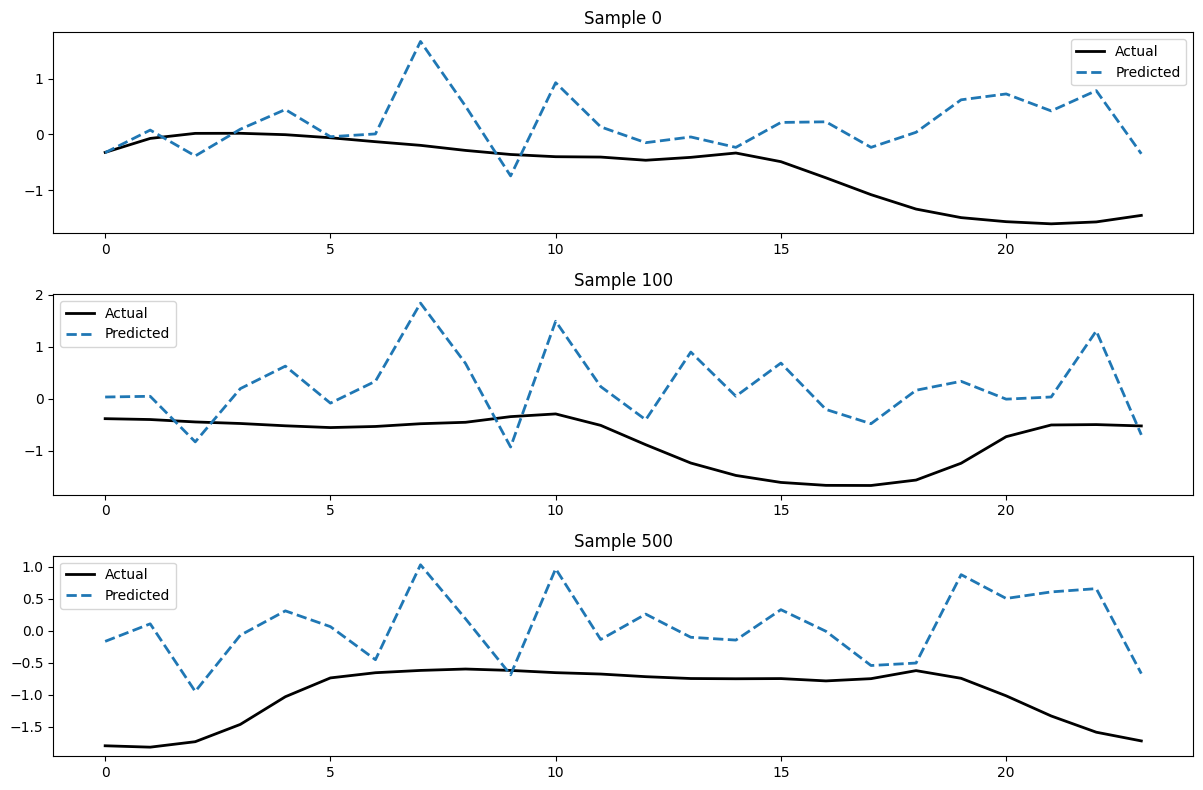

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i, sample_idx in enumerate([0, 100, 500]):
    axes[i].plot(actuals_all[sample_idx], 'k-', label='Actual', linewidth=2)
    axes[i].plot(preds_all[sample_idx], 'C0--', label='Predicted', linewidth=2)
    axes[i].set_title(f"Sample {sample_idx}")
    axes[i].legend()
plt.tight_layout()
plt.show()

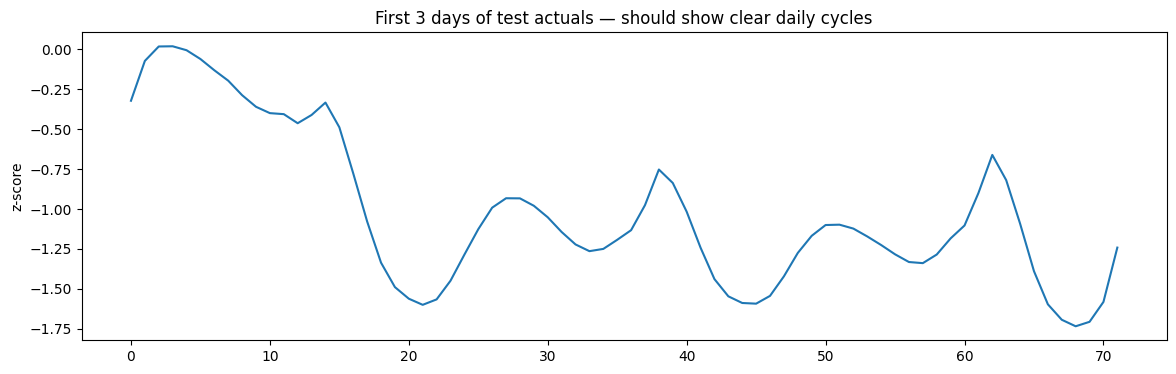

In [28]:
sample_actuals = actuals_all[::24].flatten()[:72]
plt.figure(figsize=(14, 4))
plt.plot(sample_actuals)
plt.title("First 3 days of test actuals — should show clear daily cycles")
plt.ylabel("z-score")
plt.show()

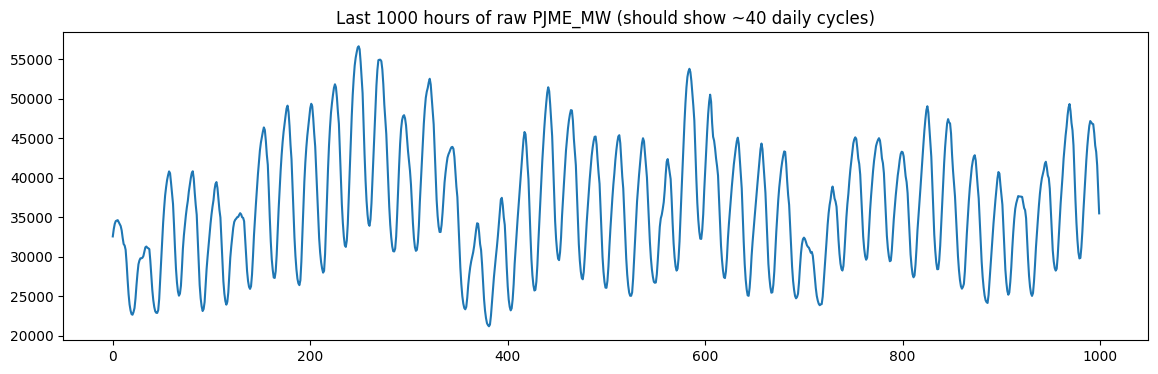

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 4))
plt.plot(df['PJME_MW'].iloc[-1000:].values)
plt.title("Last 1000 hours of raw PJME_MW (should show ~40 daily cycles)")
plt.show()

In [30]:
# Skip the dataloader, look directly at Y_test
print("Y_test shape:", Y_test.shape)

# First 3 non-overlapping 24h blocks of Y_test, flattened
direct_actuals = Y_test[::24].flatten()[:72]

plt.figure(figsize=(14, 4))
plt.plot(direct_actuals.numpy())
plt.title("Y_test directly — first 3 days, should show daily cycles")
plt.show()

NameError: name 'Y_test' is not defined

In [186]:
# Find the datetime corresponding to test_start_in_raw + window
target_start_idx = split_idx + window
print(f"First test target datetime: {df['Datetime'].iloc[target_start_idx]}")
print(f"Last test target datetime: {df['Datetime'].iloc[-1]}")

First test target datetime: 2015-04-10 07:00:00
Last test target datetime: 2018-08-03 00:00:00


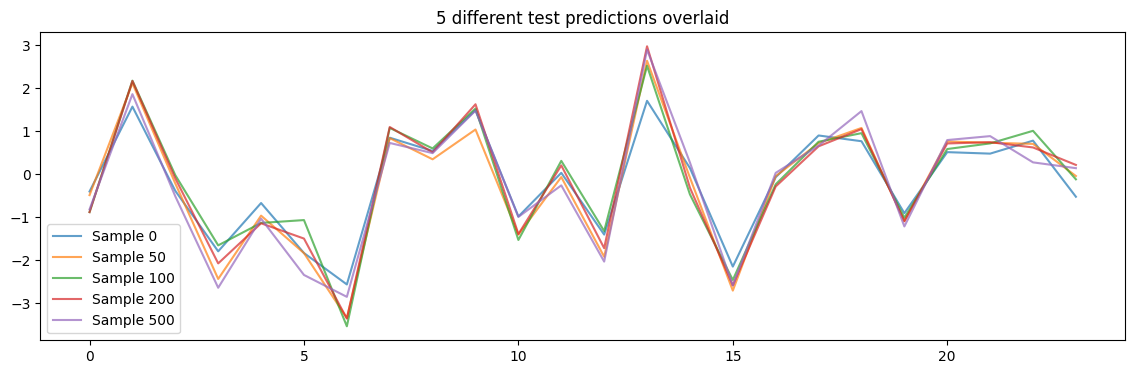

In [187]:
plt.figure(figsize=(14, 4))
for i in [0, 50, 100, 200, 500]:
    plt.plot(preds_all[i], label=f"Sample {i}", alpha=0.7)
plt.legend()
plt.title("5 different test predictions overlaid")
plt.show()